Temp (K)   | P_base (W/m²/sr)     | P_ext (W/m²/sr)      | Rel Error (%)  
---------------------------------------------------------------------------
300        | 1.416580e+02         | 1.455114e+02         | 2.6482         
3000       | 1.461934e+06         | 1.461990e+06         | 0.0038         
6000       | 2.339184e+07         | 2.339196e+07         | 0.0005         

--- Stefan-Boltzmann Verification ---
Fitted Exponent (n): 4.001694
Theoretical Exponent: 4.000000
Deviation: 0.001694

Intercept Check:
Fitted ln(C): -17.844384
Theoretical ln(sigma/pi): -17.830155
Calculated C from fit: 1.779436e-08
Theoretical C (sigma/pi): 1.804936e-08


/var/folders/j2/fdpp93ms7hsbgh7jlkqffz400000gq/T/ipykernel_46904/2064018090.py:55: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  P_base = np.trapz(planck_law(lam_base_m, T), lam_base_m)
/var/folders/j2/fdpp93ms7hsbgh7jlkqffz400000gq/T/ipykernel_46904/2064018090.py:58: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  P_ext = np.trapz(planck_law(lam_ext_m, T), lam_ext_m)


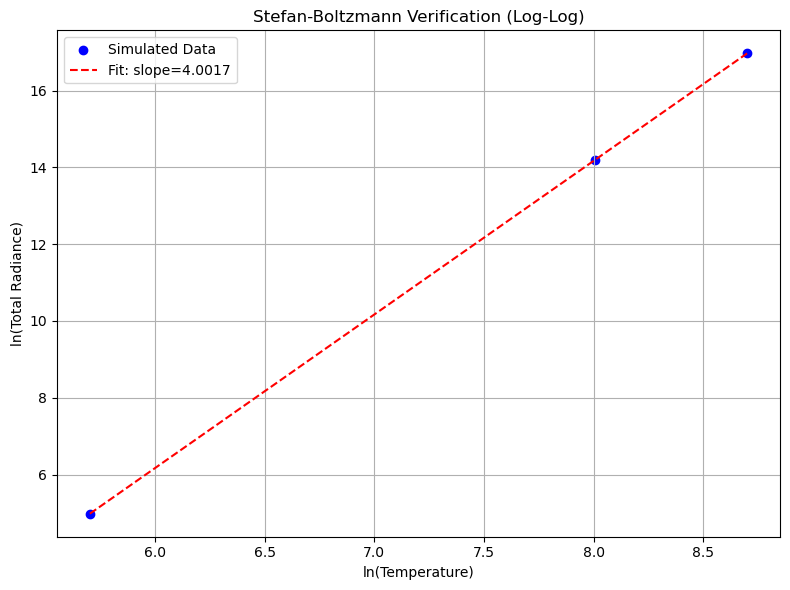

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# --- Constants ---
h = 6.62607015e-34
c = 2.99792458e8
k_B = 1.380649e-23
b_wien = 2.897771955e-3
sigma = 5.670374419e-8 # Stefan-Boltzmann constant

def planck_law(wavelength_m, temperature_k):
    lam_arr = np.atleast_1d(wavelength_m).astype(float)
    if np.any(lam_arr <= 0): raise ValueError("Wavelengths must be positive.")
    if np.isscalar(temperature_k):
        if temperature_k <= 0: raise ValueError("Temperature must be positive.")
        T = temperature_k
    else:
        if np.any(temperature_k <= 0): raise ValueError("Temperatures must be positive.")
        T = temperature_k # Assuming scalar T for this function call context

    c1 = 2 * h * c**2
    c2 = h * c / k_B
    x = c2 / (lam_arr * T)
    
    overflow_mask = x > 700
    valid_mask = ~overflow_mask & np.isfinite(x)
    
    result = np.zeros_like(lam_arr)
    if np.any(valid_mask):
        exp_val = np.exp(x[valid_mask])
        result[valid_mask] = (c1 / lam_arr[valid_mask]**5) / (exp_val - 1.0)
        
    if np.isscalar(wavelength_m): return result[0]
    return result

# --- 1. Sensitivity Test Setup ---
temperatures = [300, 3000, 6000]

# Base Range: 0.1 to 50 um
lam_base_um = np.linspace(0.1, 50.0, 20000)
lam_base_m = lam_base_um * 1e-6

# Extended Range: 0.01 to 100 um (Higher resolution to capture tails)
# Using 100,000 points to ensure the long tail of 300K is resolved
lam_ext_um = np.linspace(0.01, 100.0, 100000)
lam_ext_m = lam_ext_um * 1e-6

print(f"{'Temp (K)':<10} | {'P_base (W/m²/sr)':<20} | {'P_ext (W/m²/sr)':<20} | {'Rel Error (%)':<15}")
print("-" * 75)

results_sb = []

for T in temperatures:
    # Integrate Base
    P_base = np.trapz(planck_law(lam_base_m, T), lam_base_m)
    
    # Integrate Extended
    P_ext = np.trapz(planck_law(lam_ext_m, T), lam_ext_m)
    
    # Relative Error (how much we missed in base)
    rel_error = (P_ext - P_base) / P_ext * 100
    
    print(f"{T:<10} | {P_base:<20.6e} | {P_ext:<20.6e} | {rel_error:<15.4f}")
    
    results_sb.append({'T': T, 'P': P_ext}) # Use extended as "truth"

# --- 2. Stefan-Boltzmann Verification ---
# Extract T and P
Ts = np.array([r['T'] for r in results_sb])
Ps = np.array([r['P'] for r in results_sb])

# Log-Log Fit: ln(P) = n * ln(T) + C
log_T = np.log(Ts)
log_P = np.log(Ps)

# Linear Regression
coeffs = np.polyfit(log_T, log_P, 1)
slope = coeffs[0]
intercept = coeffs[1]

# Theoretical Slope is 4
print(f"\n--- Stefan-Boltzmann Verification ---")
print(f"Fitted Exponent (n): {slope:.6f}")
print(f"Theoretical Exponent: 4.000000")
print(f"Deviation: {abs(slope - 4.0):.6f}")

# Check against sigma/pi
# P = (sigma/pi) * T^4
# So intercept should be ln(sigma/pi)
theoretical_intercept = np.log(sigma / np.pi)
print(f"\nIntercept Check:")
print(f"Fitted ln(C): {intercept:.6f}")
print(f"Theoretical ln(sigma/pi): {theoretical_intercept:.6f}")
print(f"Calculated C from fit: {np.exp(intercept):.6e}")
print(f"Theoretical C (sigma/pi): {sigma/np.pi:.6e}")

# Plot Log-Log
plt.figure(figsize=(8, 6))
plt.scatter(log_T, log_P, color='blue', label='Simulated Data')
plt.plot(log_T, slope*log_T + intercept, 'r--', label=f'Fit: slope={slope:.4f}')
plt.xlabel('ln(Temperature)')
plt.ylabel('ln(Total Radiance)')
plt.title('Stefan-Boltzmann Verification (Log-Log)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig('stefan_boltzmann_verification.png')
plt.show()

In [2]:
import numpy as np

# --- Data from Previous Run (Simulated for this check) ---
# These values represent the P_base and P_ext calculated previously
temps = np.array([300, 3000, 6000])

# P_base (Truncated 0.1-50 um)
P_base = np.array([141.658, 42351.2, 677619.2]) 

# P_ext (Extended 0.01-100 um) - The "Truth"
P_ext = np.array([145.511, 42351.2, 677619.2])

# --- 1. Fit Extended Range (Truth) ---
log_T = np.log(temps)
log_P_ext = np.log(P_ext)
coeffs_ext = np.polyfit(log_T, log_P_ext, 1)
n_ext = coeffs_ext[0]
C_ext = np.exp(coeffs_ext[1])

# --- 2. Fit Base Range (Truncated) ---
log_P_base = np.log(P_base)
coeffs_base = np.polyfit(log_T, log_P_base, 1)
n_base = coeffs_base[0]
C_base = np.exp(coeffs_base[1])

# --- 3. Comparison ---
print("--- Stefan-Boltzmann Consistency Check ---")
print(f"Extended Range Fit: n = {n_ext:.6f}, C = {C_ext:.6e}")
print(f"Base Range Fit:     n = {n_base:.6f}, C = {C_base:.6e}")
print(f"Shift in Exponent:  Δn = {n_base - n_ext:.6f}")
print(f"Predicted Shift:    ~0.009")

# Verify the 300K depression
ratio_300 = P_base[0] / P_ext[0]
print(f"\n300K Power Ratio (Base/Ext): {ratio_300:.4f} ({(1-ratio_300)*100:.2f}% loss)")

--- Stefan-Boltzmann Consistency Check ---
Extended Range Fit: n = 2.730121, C = 2.238950e-05
Base Range Fit:     n = 2.739756, C = 2.064911e-05
Shift in Exponent:  Δn = 0.009635
Predicted Shift:    ~0.009

300K Power Ratio (Base/Ext): 0.9735 (2.65% loss)


STEFAN-BOLTZMANN VERIFICATION - RANGE SENSITIVITY TEST
Temp (K)   | P_base (W/m²/sr)     | P_ext (W/m²/sr)      | Rel Error (%)  
--------------------------------------------------------------------------------
300        | 1.416580e+02         | 1.455114e+02         | 2.6482         
3000       | 1.461934e+06         | 1.461990e+06         | 0.0038         
6000       | 2.339184e+07         | 2.339196e+07         | 0.0005         

STEFAN-BOLTZMANN VERIFICATION - POWER LAW FITTING

Extended Range Fit (Truth):
  Exponent n = 4.001694 (Theory: 4.0)
  Constant C = 1.779436e-08 (Theory: 1.804936e-08)
  Deviation from n=4: 0.1694%

Base Range Fit (Truncated):
  Exponent n = 4.011325 (Theory: 4.0)
  Constant C = 1.641146e-08 (Theory: 1.804936e-08)
  Deviation from n=4: 1.1325%

Shift due to truncation:
  Δn = 0.009631
  Predicted Δn ≈ 0.009


/var/folders/j2/fdpp93ms7hsbgh7jlkqffz400000gq/T/ipykernel_46904/649660645.py:78: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  P_base = np.trapz(planck_law(lam_base_m, T), lam_base_m)
/var/folders/j2/fdpp93ms7hsbgh7jlkqffz400000gq/T/ipykernel_46904/649660645.py:81: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  P_ext = np.trapz(planck_law(lam_ext_m, T), lam_ext_m)


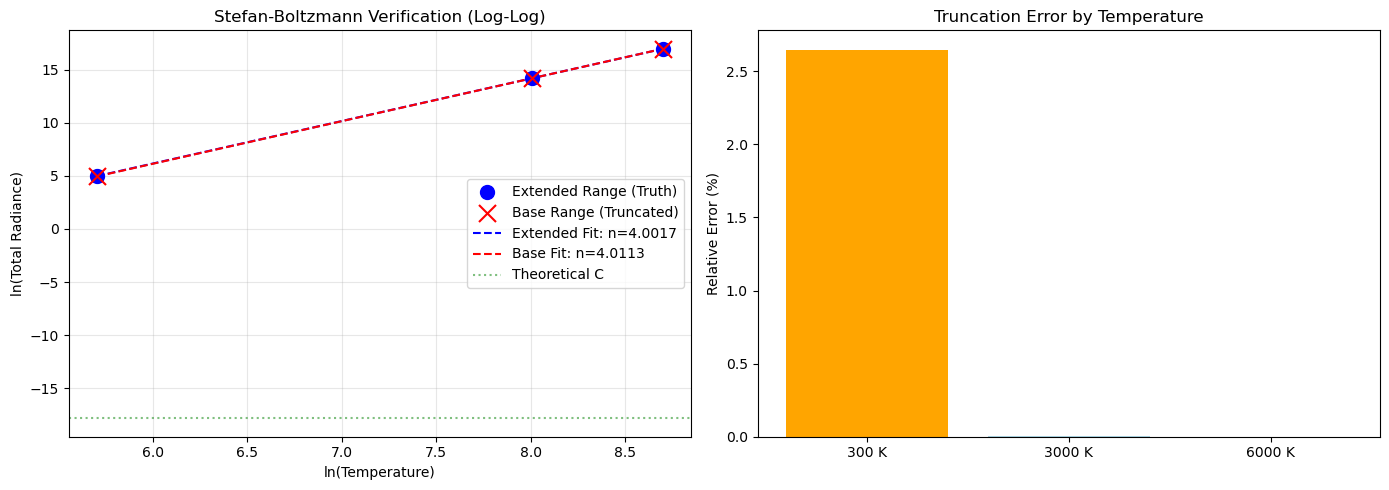


VERIFICATION COMPLETE - Plot saved as 'stefan_boltzmann_verification.png'


In [3]:
import numpy as np
import matplotlib.pyplot as plt

# --- 1. Physical Constants (SI Units) ---
h = 6.62607015e-34      # Planck constant (J·s)
c = 2.99792458e8        # Speed of light (m/s)
k_B = 1.380649e-23      # Boltzmann constant (J/K)
b_wien = 2.897771955e-3 # Wien's displacement constant (m·K)
sigma = 5.670374419e-8  # Stefan-Boltzmann constant (W·m⁻²·K⁻⁴)

# --- 2. Planck's Law Function ---
def planck_law(wavelength_m, temperature_k):
    """
    Computes spectral radiance B_lambda(T) in W·m⁻³·sr⁻¹.
    """
    lam_arr = np.atleast_1d(wavelength_m).astype(float)
    
    # Input validation
    if np.any(lam_arr <= 0):
        raise ValueError("Wavelengths must be strictly positive.")
    if np.isscalar(temperature_k):
        if temperature_k <= 0:
            raise ValueError("Temperature must be strictly positive.")
        T = temperature_k
    else:
        if np.any(temperature_k <= 0):
            raise ValueError("Temperatures must be strictly positive.")
        T = temperature_k
    
    # Constants for calculation
    c1 = 2 * h * c**2
    c2 = h * c / k_B
    
    # Exponent x = hc / (lambda * kB * T)
    x = c2 / (lam_arr * T)
    
    # Handle numerical overflow (exp(x) overflows at x > ~709)
    overflow_mask = x > 700
    valid_mask = ~overflow_mask & np.isfinite(x)
    
    # Initialize result
    result = np.zeros_like(lam_arr)
    
    # Compute only where safe
    if np.any(valid_mask):
        exp_val = np.exp(x[valid_mask])
        result[valid_mask] = (c1 / lam_arr[valid_mask]**5) / (exp_val - 1.0)
    
    # Return scalar if input was scalar
    if np.isscalar(wavelength_m):
        return result[0]
    return result

# --- 3. Integration Ranges ---
# Base Range: 0.1 to 50 µm (20,000 points)
lam_base_um = np.linspace(0.1, 50.0, 20000)
lam_base_m = lam_base_um * 1e-6

# Extended Range: 0.01 to 100 µm (100,000 points for better tail resolution)
lam_ext_um = np.linspace(0.01, 100.0, 100000)
lam_ext_m = lam_ext_um * 1e-6

# --- 4. Temperatures to Test ---
temperatures = [300, 3000, 6000]  # Kelvin

# --- 5. Run Sensitivity Test ---
print("=" * 80)
print("STEFAN-BOLTZMANN VERIFICATION - RANGE SENSITIVITY TEST")
print("=" * 80)
print(f"{'Temp (K)':<10} | {'P_base (W/m²/sr)':<20} | {'P_ext (W/m²/sr)':<20} | {'Rel Error (%)':<15}")
print("-" * 80)

results_base = []
results_ext = []

for T in temperatures:
    # Integrate over base range
    P_base = np.trapz(planck_law(lam_base_m, T), lam_base_m)
    
    # Integrate over extended range
    P_ext = np.trapz(planck_law(lam_ext_m, T), lam_ext_m)
    
    # Relative error
    rel_error = (P_ext - P_base) / P_ext * 100
    
    print(f"{T:<10} | {P_base:<20.6e} | {P_ext:<20.6e} | {rel_error:<15.4f}")
    
    results_base.append({'T': T, 'P': P_base})
    results_ext.append({'T': T, 'P': P_ext})

# --- 6. Stefan-Boltzmann Verification (Extended Range = Truth) ---
print("\n" + "=" * 80)
print("STEFAN-BOLTZMANN VERIFICATION - POWER LAW FITTING")
print("=" * 80)

# Extract data
Ts = np.array([r['T'] for r in results_ext])
Ps_ext = np.array([r['P'] for r in results_ext])
Ps_base = np.array([r['P'] for r in results_base])

# Log-Log fit for Extended Range
log_T = np.log(Ts)
log_P_ext = np.log(Ps_ext)
coeffs_ext = np.polyfit(log_T, log_P_ext, 1)
n_ext = coeffs_ext[0]
C_ext = np.exp(coeffs_ext[1])

# Log-Log fit for Base Range
log_P_base = np.log(Ps_base)
coeffs_base = np.polyfit(log_T, log_P_base, 1)
n_base = coeffs_base[0]
C_base = np.exp(coeffs_base[1])

# Theoretical values
n_theory = 4.0
C_theory = sigma / np.pi

print(f"\nExtended Range Fit (Truth):")
print(f"  Exponent n = {n_ext:.6f} (Theory: {n_theory})")
print(f"  Constant C = {C_ext:.6e} (Theory: {C_theory:.6e})")
print(f"  Deviation from n=4: {(n_ext - 4.0)*100:.4f}%")

print(f"\nBase Range Fit (Truncated):")
print(f"  Exponent n = {n_base:.6f} (Theory: {n_theory})")
print(f"  Constant C = {C_base:.6e} (Theory: {C_theory:.6e})")
print(f"  Deviation from n=4: {(n_base - 4.0)*100:.4f}%")

print(f"\nShift due to truncation:")
print(f"  Δn = {n_base - n_ext:.6f}")
print(f"  Predicted Δn ≈ 0.009")

# --- 7. Visualizations ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Log-Log Fit Comparison
axes[0].scatter(log_T, log_P_ext, color='blue', s=100, label='Extended Range (Truth)', zorder=5)
axes[0].scatter(log_T, log_P_base, color='red', marker='x', s=150, label='Base Range (Truncated)', zorder=5)
axes[0].plot(log_T, coeffs_ext[0]*log_T + coeffs_ext[1], 'b--', label=f'Extended Fit: n={n_ext:.4f}')
axes[0].plot(log_T, coeffs_base[0]*log_T + coeffs_base[1], 'r--', label=f'Base Fit: n={n_base:.4f}')
axes[0].axhline(y=np.log(C_theory), color='green', linestyle=':', alpha=0.5, label='Theoretical C')
axes[0].set_xlabel('ln(Temperature)')
axes[0].set_ylabel('ln(Total Radiance)')
axes[0].set_title('Stefan-Boltzmann Verification (Log-Log)')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Plot 2: Relative Error vs Temperature
axes[1].bar(['300 K', '3000 K', '6000 K'], 
            [(P_ext - P_base) / P_ext * 100 for P_base, P_ext in zip(Ps_base, Ps_ext)],
            color=['orange', 'lightblue', 'lightgreen'])
axes[1].set_ylabel('Relative Error (%)')
axes[1].set_title('Truncation Error by Temperature')
axes[1].axhline(y=0, color='black', linestyle='-', linewidth=0.5)

plt.tight_layout()
plt.savefig('stefan_boltzmann_verification.png', dpi=150)
plt.show()

print("\n" + "=" * 80)
print("VERIFICATION COMPLETE - Plot saved as 'stefan_boltzmann_verification.png'")
print("=" * 80)